# GNN Notebook test

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from math import sqrt

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole
from tqdm import tqdm

import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import AttentiveFP

#-------------------

import os 
import random
from collections import Counter

import torch

from torch_geometric.data import InMemoryDataset, download_url, extract_gz
from sklearn.metrics import r2_score


# print(plt.style.available)
plt.style.use('ggplot')

/opt/miniconda3/envs/gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed=420):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

### Init Data

In [15]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")
import numpy as np

path = PROJECT_ROOT / "Data" / "toxicity_fish.csv"

df = pd.read_csv(path)

selected_columns = ["SMILES", "conc"] 
df = df[selected_columns][0:200]

print("Success! File loaded.")
print(df.head())
print(df.describe())
print(f"Number of unique SMILES: {df['SMILES'].nunique()}")

Success! File loaded.
       SMILES  conc
0  O=[O+][O-]  0.18
1  O=[O+][O-]  0.18
2  O=[O+][O-]  0.26
3  O=[O+][O-]  0.26
4  O=[O+][O-]  0.17
              conc
count   200.000000
mean     60.373048
std     200.805911
min       0.001200
25%       0.177500
50%       7.420000
75%      54.025000
max    1850.000000
Number of unique SMILES: 29


In [16]:
# Add a molecule column to the DataFrame
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='Molecule')

# Add molecular weight column
df['MolecularWeight'] = df['Molecule'].apply(Descriptors.MolWt)

df.head()

,SMILES,conc,Molecule,MolecularWeight
0,O=[O+][O-],0.18,<rdkit.Chem.rdchem.Mol object at 0x323f027a0>,47.997
1,O=[O+][O-],0.18,<rdkit.Chem.rdchem.Mol object at 0x323f01d90>,47.997
2,O=[O+][O-],0.26,<rdkit.Chem.rdchem.Mol object at 0x323f02810>,47.997
3,O=[O+][O-],0.26,<rdkit.Chem.rdchem.Mol object at 0x323f028f0>,47.997
4,O=[O+][O-],0.17,<rdkit.Chem.rdchem.Mol object at 0x323f02960>,47.997


### Data Analysis

/var/folders/tm/njt433vn0837p6hm19jr4_5c0000gn/T/ipykernel_29340/1882244044.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='SMILES', y='Count', palette='viridis')
/var/folders/tm/njt433vn0837p6hm19jr4_5c0000gn/T/ipykernel_29340/1882244044.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


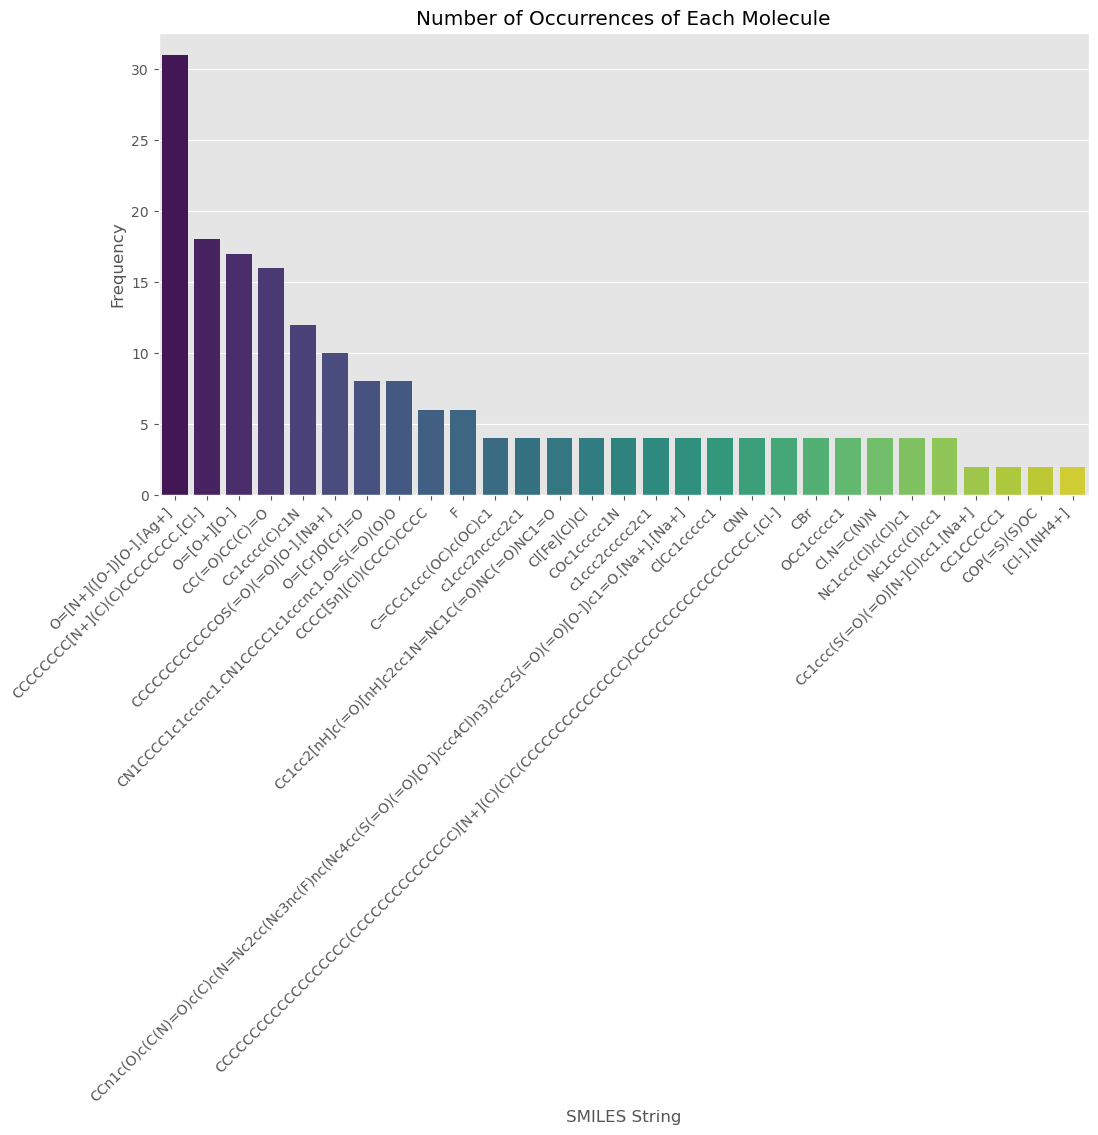

In [17]:

counts = Counter(df['SMILES'])
# print(counts)
plot_df = pd.DataFrame(counts.items(), columns=['SMILES', 'Count'])

plot_df = plot_df.sort_values('Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='SMILES', y='Count', palette='viridis')

plt.title('Number of Occurrences of Each Molecule')
plt.xlabel('SMILES String')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Look at one molecule

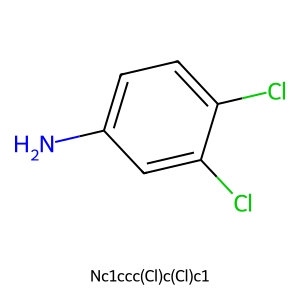

In [18]:
# Draw molecular structure
mol_id = 16
img = Draw.MolToImage(df['Molecule'][mol_id], legend=str(df['SMILES'][mol_id]))
display(img)

### Pytorch Geometric

In [19]:
from torch_geometric.utils import from_smiles

# Convert SMILES to PyG graph data objects
smiles = df['SMILES'].tolist()
smiles_pyg = [from_smiles(s, with_hydrogen=False) for s in smiles]
print(type(smiles_pyg[0]))

print(smiles[mol_id])
print(smiles_pyg)



<class 'torch_geometric.data.data.Data'>
Nc1ccc(Cl)c(Cl)c1
[Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]'), Data(x=[8, 9], edge_index=[2, 16], edge_attr=[16, 3], smiles='ClCc1ccccc1'), Data(x=[8, 9], edge_index=[2, 16], edge_attr=[16, 3], smiles='ClCc1ccccc1'), Data(x=[8, 9], edge_index=[2, 16], edge_attr=[16, 3], smiles='ClCc1ccccc1'), Data(x=[8, 9], edge_index=[2, 16], edge_attr=[16, 3], smiles='ClCc1ccccc1'), Data(x=[8, 9], edge_index=[2, 16], edge_

### Netowrkx

<class 'networkx.classes.digraph.DiGraph'>


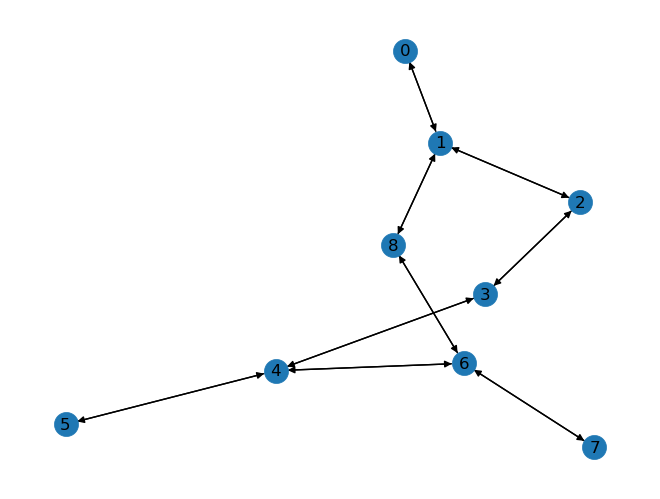

In [20]:
from torch_geometric.utils import to_networkx

# Convert to networkx graph
smiles_nx = [to_networkx(graph) for graph in smiles_pyg]
print(type(smiles_nx[0]))

nx.draw(smiles_nx[mol_id], with_labels=True)

### DeepChem

In [21]:
import deepchem as dc

# Convert to deepchem
featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)
smiles_dc = featurizer.featurize(df['SMILES'].tolist())

print(type(smiles_dc[0]))

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/opt/miniconda3/envs/gnn/lib/python3.11/site-packages/deep

<class 'deepchem.feat.graph_data.GraphData'>


## GNN